<a href="https://colab.research.google.com/github/biancamariciuc/Messenger/blob/main/simple_unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!cp -r "/content/drive/MyDrive/thesis/dataset" "/content"

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import os

class GLENDADataset(Dataset):
    def __init__(self, root_dir, split):
        self.hr_path = os.path.join(root_dir, split, 'hr')
        self.lr_path = os.path.join(root_dir, split, 'lr')
        self.filenames = sorted(os.listdir(self.hr_path))

        # convert to Tensor (0-1 range)
        self.transform = T.Compose([T.ToTensor()])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]

        hr_img = Image.open(os.path.join(self.hr_path, name)).convert('RGB')
        lr_img = Image.open(os.path.join(self.lr_path, name)).convert('RGB')
        hr_tensor = self.transform(hr_img)

        # Pre-upscale LR to match HR size
        # This makes the U-Net an "Image-to-Image" restoration network
        lr_upscaled = lr_img.resize(hr_img.size, Image.BICUBIC)
        lr_tensor = self.transform(lr_upscaled)

        return lr_tensor, hr_tensor


train_ds = GLENDADataset("/content/dataset", split='train')
val_ds   = GLENDADataset("/content/dataset", split='val')

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

In [4]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

class OriginalUNetSR(nn.Module):
    def __init__(self):
        super(OriginalUNetSR, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=0),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=0),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = conv_block(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)


        self.final = nn.Conv2d(64, 3, kernel_size=1)

    def crop(self, tensor_from_encoder, tensor_from_decoder):
        """Cuts the borders off the encoder tensor to match the decoder tensor size"""
        target_size = tensor_from_decoder.shape[2]
        current_size = tensor_from_encoder.shape[2]

        # Calculate how many pixels to cut from the edges
        delta = (current_size - target_size) // 2

        # Slice the tensor to cut off the borders
        return tensor_from_encoder[:, :, delta:current_size-delta, delta:current_size-delta]

    def forward(self, x):
        # Down
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottom
        b = self.bottleneck(self.pool(e4))

        # Up (Notice we MUST crop before we concatenate!)
        d4 = self.up4(b)
        e4_cropped = self.crop(e4, d4)
        d4 = torch.cat((d4, e4_cropped), dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        e3_cropped = self.crop(e3, d3)
        d3 = torch.cat((d3, e3_cropped), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        e2_cropped = self.crop(e2, d2)
        d2 = torch.cat((d2, e2_cropped), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        e1_cropped = self.crop(e1, d1)
        d1 = torch.cat((d1, e1_cropped), dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [9]:
import torch.nn as nn

class UNetSR(nn.Module):
    def __init__(self):
        super(UNetSR, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = conv_block(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetSR().to(device)

# criterion = nn.MSELoss()
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 50

In [12]:

save_path = "/content/drive/MyDrive/thesis/my_models/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for lr_batch, hr_batch in train_loader:
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

        optimizer.zero_grad()
        output = model(lr_batch)
        loss = criterion(output, hr_batch)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(train_loader):.6f}")

    model_name = f"unet_baseline_epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), model_name)
    torch.save(model.state_dict(), os.path.join(save_path, model_name))



Epoch 1/50, Loss: 0.046468
Epoch 2/50, Loss: 0.027396
Epoch 3/50, Loss: 0.026119
Epoch 4/50, Loss: 0.024860
Epoch 5/50, Loss: 0.024474
Epoch 6/50, Loss: 0.023860
Epoch 7/50, Loss: 0.023667
Epoch 8/50, Loss: 0.023377
Epoch 9/50, Loss: 0.023466
Epoch 10/50, Loss: 0.022947
Epoch 11/50, Loss: 0.022422
Epoch 12/50, Loss: 0.022549
Epoch 13/50, Loss: 0.022271
Epoch 14/50, Loss: 0.021885
Epoch 15/50, Loss: 0.021650
Epoch 16/50, Loss: 0.021001
Epoch 17/50, Loss: 0.020996
Epoch 18/50, Loss: 0.020576
Epoch 19/50, Loss: 0.020794
Epoch 20/50, Loss: 0.020960
Epoch 21/50, Loss: 0.020552
Epoch 22/50, Loss: 0.019798
Epoch 23/50, Loss: 0.019663
Epoch 24/50, Loss: 0.019631
Epoch 25/50, Loss: 0.019871
Epoch 26/50, Loss: 0.019399
Epoch 27/50, Loss: 0.019433
Epoch 28/50, Loss: 0.019350
Epoch 29/50, Loss: 0.018698
Epoch 30/50, Loss: 0.018572
Epoch 31/50, Loss: 0.018424
Epoch 32/50, Loss: 0.018757
Epoch 33/50, Loss: 0.018199
Epoch 34/50, Loss: 0.018224
Epoch 35/50, Loss: 0.018152
Epoch 36/50, Loss: 0.017570
E

#Here is the code for testing

Loading weights from: /content/drive/MyDrive/thesis/my_models/unet_baseline_epoch_50.pth
Starting evaluation on Validation Set...
----------------------------------------
Final Validation Results:
Avg Loss (MSE): 0.000775
Avg PSNR:       31.61 dB
----------------------------------------


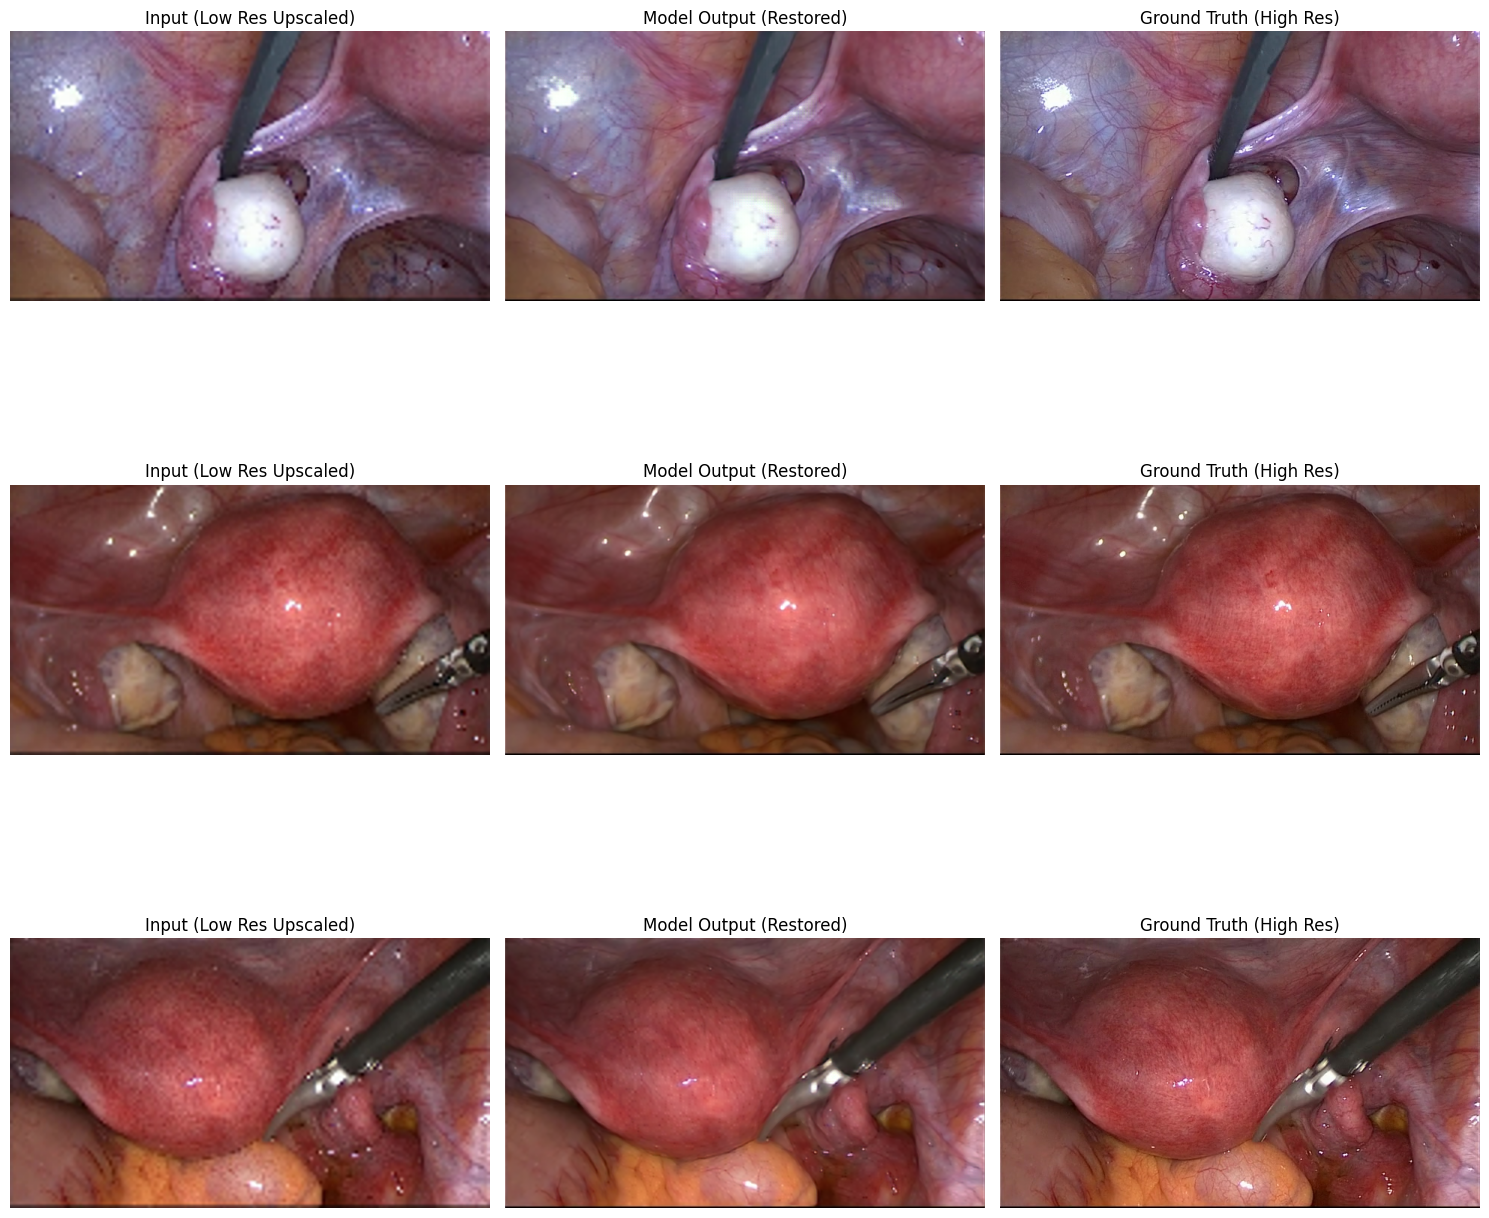

In [14]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def calculate_psnr(sr, hr):
    mse = torch.mean((sr - hr) ** 2, dim=[1,2,3])  # per image
    psnr = 10 * torch.log10(1.0 / mse)
    return psnr.mean()

def show_results(lr, sr, hr, num_images=3):
    """Visualizes Input, Super-Resolution Output, and Ground Truth"""
    lr = lr.cpu().clamp(0, 1)
    sr = sr.cpu().clamp(0, 1)
    hr = hr.cpu().clamp(0, 1)

    plt.figure(figsize=(15, 5 * num_images))
    for i in range(min(num_images, len(lr))):
        # LR Image
        plt.subplot(num_images, 3, i * 3 + 1)
        plt.imshow(lr[i][:3].permute(1,2,0).numpy())
        # plt.imshow(lr[i].permute(1, 2, 0).numpy())
        plt.title("Input (Low Res Upscaled)")
        plt.axis('off')

        # Model Output
        plt.subplot(num_images, 3, i * 3 + 2)
        plt.imshow(sr[i].permute(1, 2, 0).numpy())
        plt.title("Model Output (Restored)")
        plt.axis('off')

        # HR Image
        plt.subplot(num_images, 3, i * 3 + 3)
        plt.imshow(hr[i].permute(1, 2, 0).numpy())
        plt.title("Ground Truth (High Res)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


model = UNetSR().to(device)

weights_path = "/content/drive/MyDrive/thesis/my_models/unet_baseline_epoch_50.pth"

if os.path.exists(weights_path):
    print(f"Loading weights from: {weights_path}")
    model.load_state_dict(torch.load(weights_path, map_location=device))
else:
    print(f"Error: File not found at {weights_path}. Check the epoch number.")

model.eval()
criterion = nn.MSELoss()

total_loss = 0
total_psnr = 0
num_batches = 0

sample_lr, sample_sr, sample_hr = [], [], []

print("Starting evaluation on Validation Set...")

with torch.no_grad():
    for lr_batch, hr_batch in val_loader:
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)


        output = model(lr_batch)


        loss = criterion(output, hr_batch)
        psnr = calculate_psnr(output, hr_batch)

        total_loss += loss.item()
        total_psnr += psnr.item()
        num_batches += 1

        # Save the first batch for visualization
        if len(sample_lr) == 0:
            sample_lr = lr_batch
            sample_sr = output
            sample_hr = hr_batch

avg_loss = total_loss / num_batches
avg_psnr = total_psnr / num_batches

print("-" * 40)
print(f"Final Validation Results:")
print(f"Avg Loss (MSE): {avg_loss:.6f}")
print(f"Avg PSNR:       {avg_psnr:.2f} dB")
print("-" * 40)

show_results(sample_lr, sample_sr, sample_hr, num_images=3)